## 1. Librerías

In [69]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [70]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


In [71]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [72]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [73]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(63, 60)
(16, 60)


## 4. Optimización de Hiperparámetros con Optuna

In [74]:
max_lag = 5  # por el moving average 5

# Configurar Optuna para que no muestre logs verbosos
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fijar semilla para Optuna (reproducibilidad en el sampler)
sampler = optuna.samplers.TPESampler(seed=SEED)

In [75]:
def objective(trial):
    # Espacios de búsqueda BALANCEADOS para ~63 filas y 60 features
    # Objetivo: evitar overfitting sin caer en underfitting
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "feature_pre_filter": False,

        # Learning rate moderado
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        # Árboles simples pero no demasiado
        "num_leaves": trial.suggest_int("num_leaves", 6, 20),
        "max_depth": trial.suggest_int("max_depth", 2, 5),

        # Regularizaciones MODERADAS (punto medio)
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1.0, 15.0, log=True),

        # Mínimos balanceados
        "min_child_samples": trial.suggest_int("min_child_samples", 8, 25),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.1, 1.0),

        # Submuestreo moderado
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),

        # Árboles moderados
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1
        eff["bagging_seed"] = SEED

    # Semilla para muestreo de features
    if eff["colsample_bytree"] < 1.0:
        eff["feature_fraction_seed"] = SEED

    # --------------------------------------------------------------------------

    # Cross validation ajustado para dataset pequeño
    n_splits = 3
    test_size = 8
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [76]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor RMSE CV promedio: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin


RESULTADOS DE LA OPTIMIZACIÓN

Mejor RMSE CV promedio: 123093.8628

Mejores hiperparámetros:
  - learning_rate: 0.06628586642821484
  - num_leaves: 12
  - max_depth: 3
  - lambda_l1: 0.11941456185338455
  - lambda_l2: 1.0487072869540897
  - min_child_samples: 8
  - min_split_gain: 0.8590511818260552
  - subsample: 0.8988049595242307
  - colsample_bytree: 0.7970375588011442
  - n_estimators: 182


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

In [77]:
# Entrenamiento del modelo final con mejores parámetros

best_params = study.best_params.copy()
best_params['random_state'] = SEED  # Asegurar semilla en modelo final

# Agregar semillas adicionales si es necesario
if best_params.get('subsample', 1.0) < 1.0:
    best_params['bagging_seed'] = SEED
if best_params.get('colsample_bytree', 1.0) < 1.0:
    best_params['feature_fraction_seed'] = SEED

best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.11941456185338455, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11941456185338455
[LightGBM] [Warning] lambda_l2 is set=1.0487072869540897, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0487072869540897
[LightGBM] [Warning] lambda_l1 is set=0.11941456185338455, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11941456185338455
[LightGBM] [Warning] lambda_l2 is set=1.0487072869540897, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0487072869540897
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 63, number of used features: 60
[LightGBM] [Info] Start training from score 2435670.507937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

LGBMRegressor(bagging_seed=42, colsample_bytree=0.7970375588011442,
              feature_fraction_seed=42, lambda_l1=0.11941456185338455,
              lambda_l2=1.0487072869540897, learning_rate=0.06628586642821484,
              max_depth=3, min_child_samples=8,
              min_split_gain=0.8590511818260552, n_estimators=182,
              num_leaves=12, random_state=42, subsample=0.8988049595242307)

## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [78]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

[LightGBM] [Warning] lambda_l1 is set=0.11941456185338455, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11941456185338455
[LightGBM] [Warning] lambda_l2 is set=1.0487072869540897, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0487072869540897

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 264011.0662
Holdout R²:   -8.5733
Error relativo (holdout): 12.11%


### 5.2. Visualización de predicciones

In [79]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

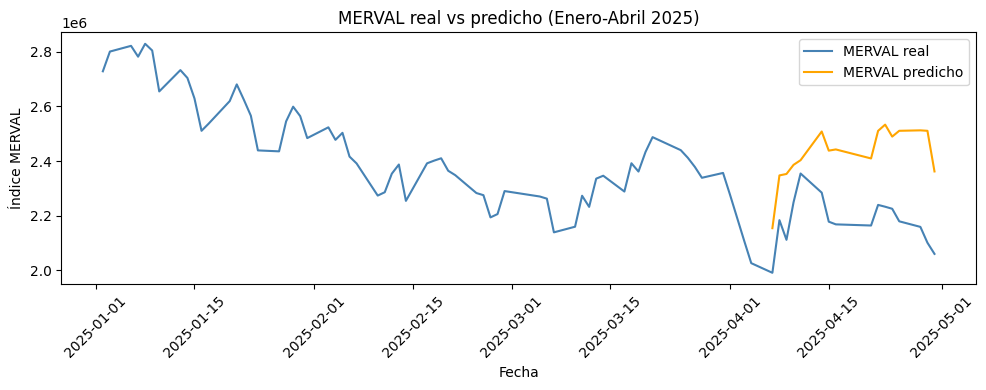

In [80]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (Enero-Abril 2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

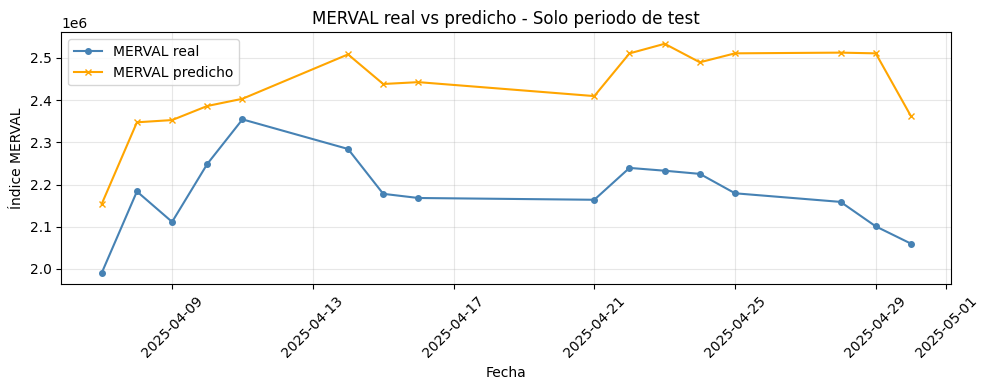

In [81]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

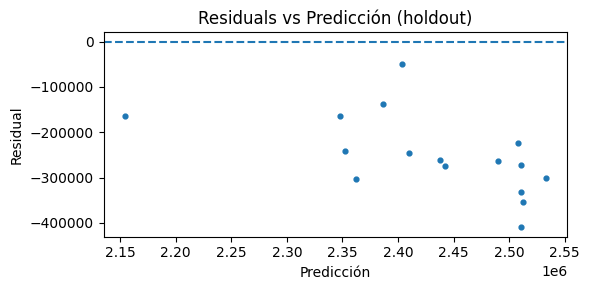

In [82]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

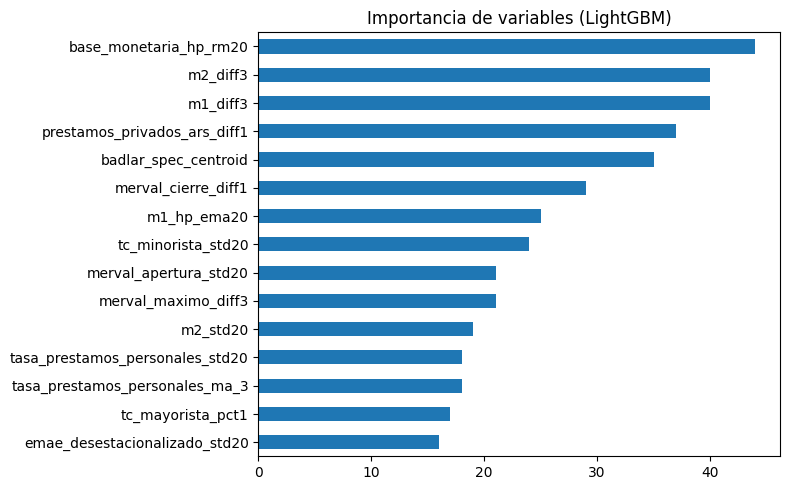

In [83]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()


## 6. Conclusiones

### Resultado Principal

El modelo LightGBM optimizado con Optuna presenta **overfitting severo** en el dataset reducido:
- **RMSE CV**: 123,093.86
- **RMSE Test**: 264,011.07 (114% más alto que CV)
- **R²**: -8.57 (el modelo es mucho peor que predecir la media constante)
- **Error relativo**: 12.11%

### Análisis del Problema Fundamental

#### Curse of Dimensionality

El problema principal es la **proporción samples-to-features extremadamente baja**:
- **63 observaciones de entrenamiento**
- **60 features** 
- **Ratio 1.05:1** (idealmente debería ser al menos 10:1 o mayor)

Esta proporción hace que el overfitting sea prácticamente inevitable. El modelo memoriza patrones de ruido en el conjunto de entrenamiento que no generalizan a datos nuevos, resultando en un gap masivo de +114% entre RMSE CV y RMSE Test.

#### Diagnóstico del Overfitting

**Evidencia:**
- El RMSE en CV (123k) sugiere que el modelo está aprendiendo patrones en el conjunto de entrenamiento
- El RMSE en Test (264k) revela que lo aprendido no generaliza a datos nuevos
- R² negativo indica predicciones peores que un modelo trivial que predice la media constante

**Causa raíz:** Con tan pocas observaciones relativas al número de features, el modelo no puede distinguir entre señal verdadera y ruido aleatorio. Cada feature adicional aumenta la capacidad del modelo para "memorizar" los datos de entrenamiento sin capturar relaciones genuinas.

### Hiperparámetros Óptimos Encontrados

La optimización con Optuna (50 trials) encontró la siguiente configuración balanceada:

- **Learning rate**: 0.066 (moderado para aprendizaje controlado)
- **Complejidad de árboles**: `num_leaves=12`, `max_depth=3` (árboles simples)
- **Regularización**: `lambda_l1=0.12`, `lambda_l2=1.05` (moderada)
- **Restricciones de split**: `min_child_samples=8`, `min_split_gain=0.86` (restrictivos)
- **Submuestreo**: `subsample=0.90`, `colsample_bytree=0.80` (alto)
- **Número de árboles**: 182

A pesar de utilizar hiperparámetros conservadores diseñados para prevenir overfitting (árboles simples, regularización, splits restrictivos), las limitaciones fundamentales del dataset hacen imposible lograr una buena generalización.

### Limitaciones del Modelo

#### Por qué LightGBM no funciona en este dataset

1. **Datos insuficientes**: 63 observaciones no son suficientes para aprender relaciones robustas entre 60 features sin memorizar ruido. Los modelos de gradient boosting necesitan datos abundantes para funcionar correctamente.

2. **Cross-validation poco representativa**: El TimeSeriesSplit con 3 folds y sets de validación pequeños (8 observaciones) no refleja adecuadamente el desempeño en el conjunto de test. Los folds de CV están altamente correlacionados y no capturan la variabilidad del período de test.

3. **Features con ruido**: En un período corto de 4 meses, es probable que muchas de las 60 features contengan más ruido que señal predictiva real. Variables macroeconómicas y financieras pueden comportarse erráticamente en ventanas temporales cortas.

4. **Comportamiento de mercado**: El MERVAL en períodos cortos tiende a tener alta volatilidad y comportamiento cercano a un Random Walk, donde movimientos futuros no son predecibles mediante patrones históricos complejos.

### Conclusión Final

**LightGBM no es adecuado para este dataset reducido de 4 meses (Enero-Abril 2025)**. 

El modelo presenta:
- ✗ Overfitting severo e inevitable (gap CV→Test de +114%)
- ✗ R² profundamente negativo (-8.57)
- ✗ Incapacidad de generalizar a pesar de optimización exhaustiva y regularización
- ✗ Error relativo del 12% que no es aceptable para predicción financiera

La raíz del problema no es la configuración de hiperparámetros, sino la **incompatibilidad fundamental entre el tamaño del dataset y la complejidad del modelo**.

### Recomendaciones

Para trabajar con este dataset de tamaño limitado, se sugiere:

1. **Reducción de features drástica**: 
   - Seleccionar solo las top 5-10 features más importantes mediante feature selection
   - Mejorar el ratio samples-to-features a niveles más manejables (~6:1 o mejor)
   - Reducir el riesgo de overfitting al disminuir la dimensionalidad

2. **Modelos más simples**:
   - Regresión lineal con regularización (Ridge, Lasso, ElasticNet)
   - Modelos parsimoniosos que requieren menos datos para entrenar adecuadamente
   - Evitar modelos de alta complejidad como gradient boosting

3. **Expandir el dataset temporal**:
   - Si es posible, incluir más historia (6-12 meses mínimo)
   - LightGBM necesita al menos 200-300 observaciones para 60 features
   - Un dataset más grande permitiría explotar el poder predictivo del modelo

4. **Feature engineering parsimoniosa**:
   - En lugar de 60 features, crear pocas features temporales robustas
   - Usar técnicas de reducción de dimensionalidad (PCA, feature importance)
   - Priorizar calidad sobre cantidad de variables predictoras

**Veredicto final**: Los modelos de gradient boosting como LightGBM requieren significativamente más datos para funcionar adecuadamente. Con solo 4 meses de historia, modelos más simples son la opción más apropiada.